### Estacionariedad 

<div class="alert alert-block alert-success"> Una Serie de Tiempo es estacionaria si su media y desviación estándar NO cambian a lo largo del tiempo </div>

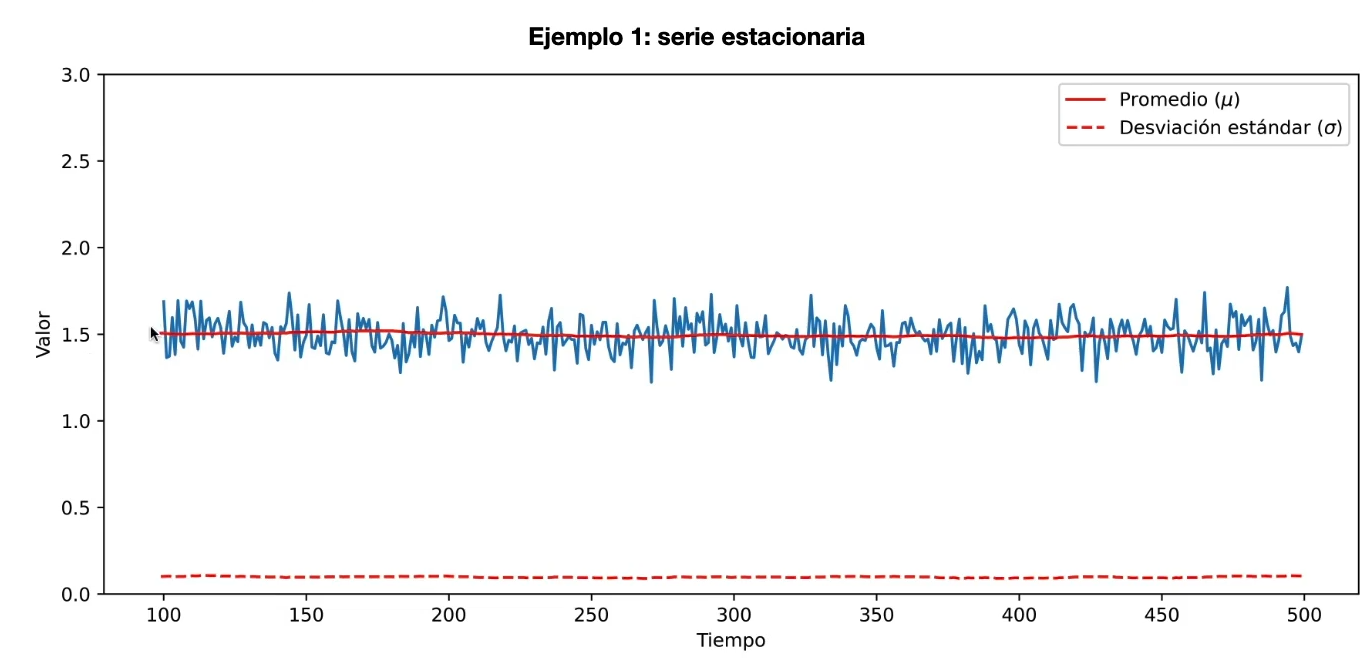

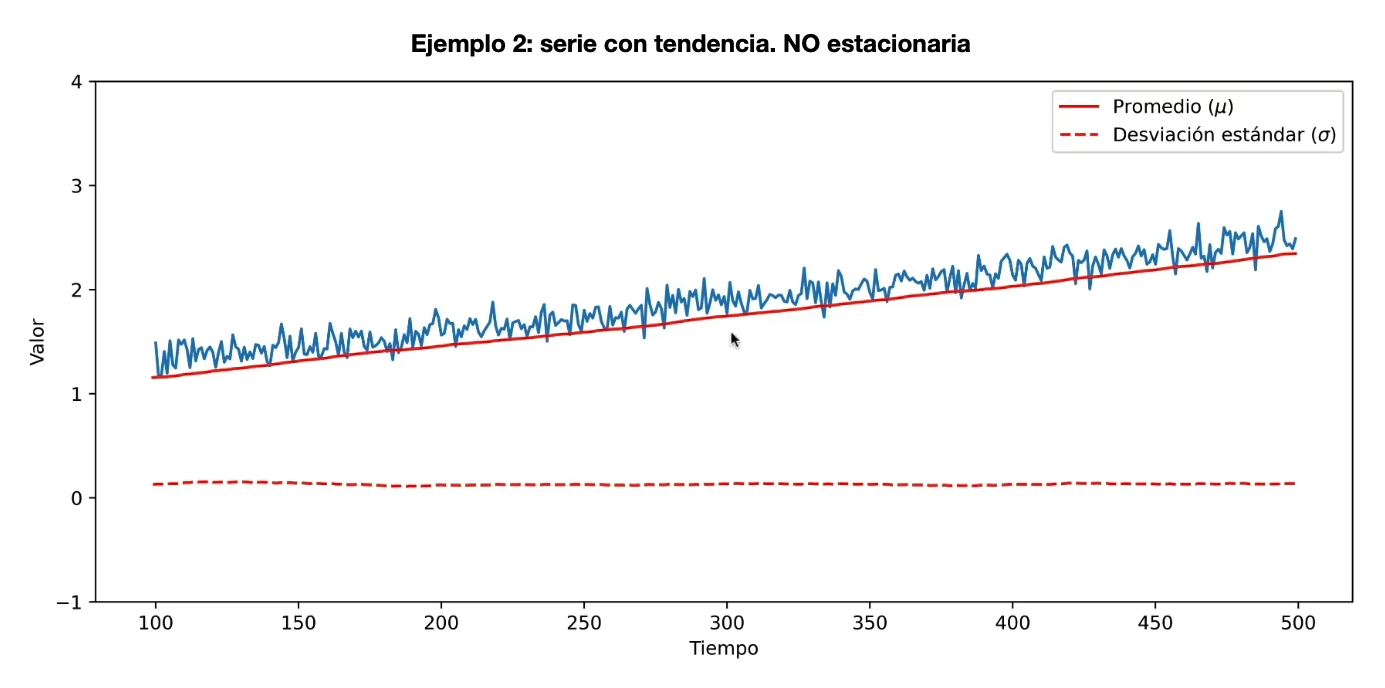

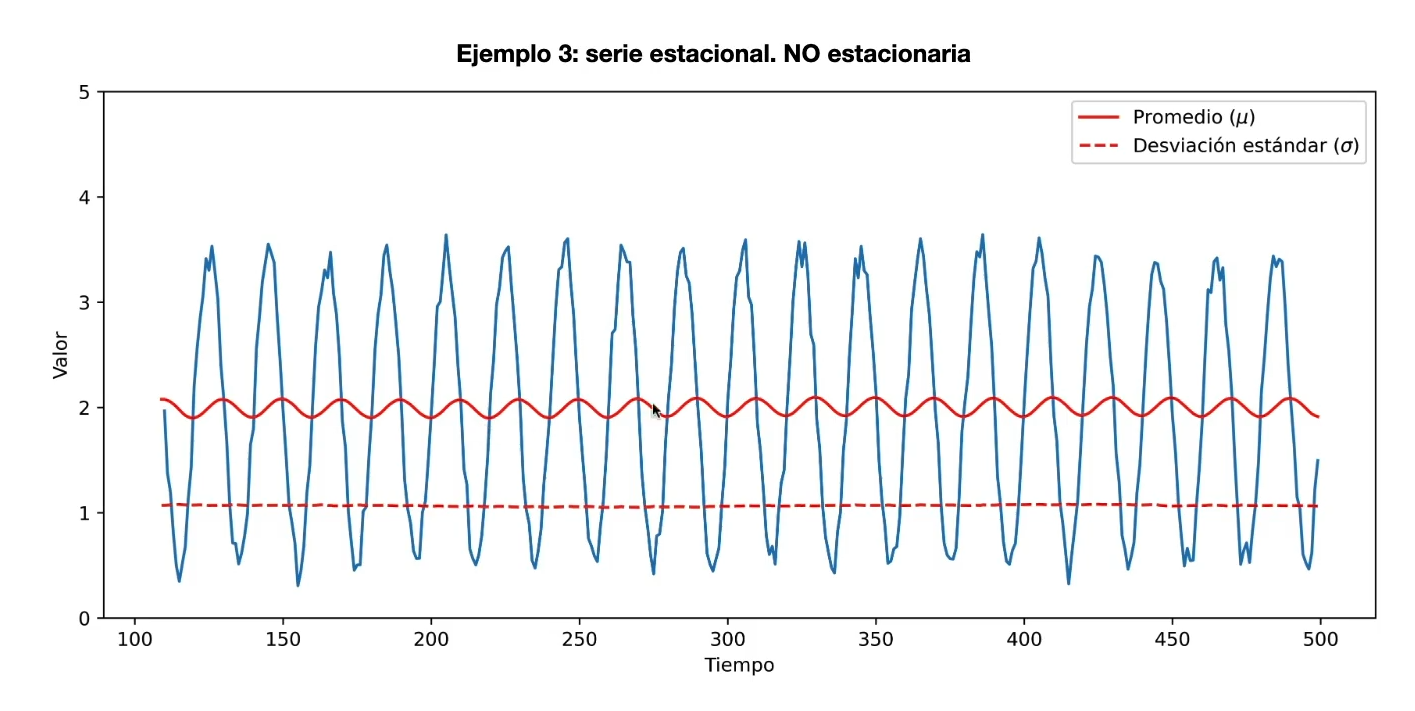

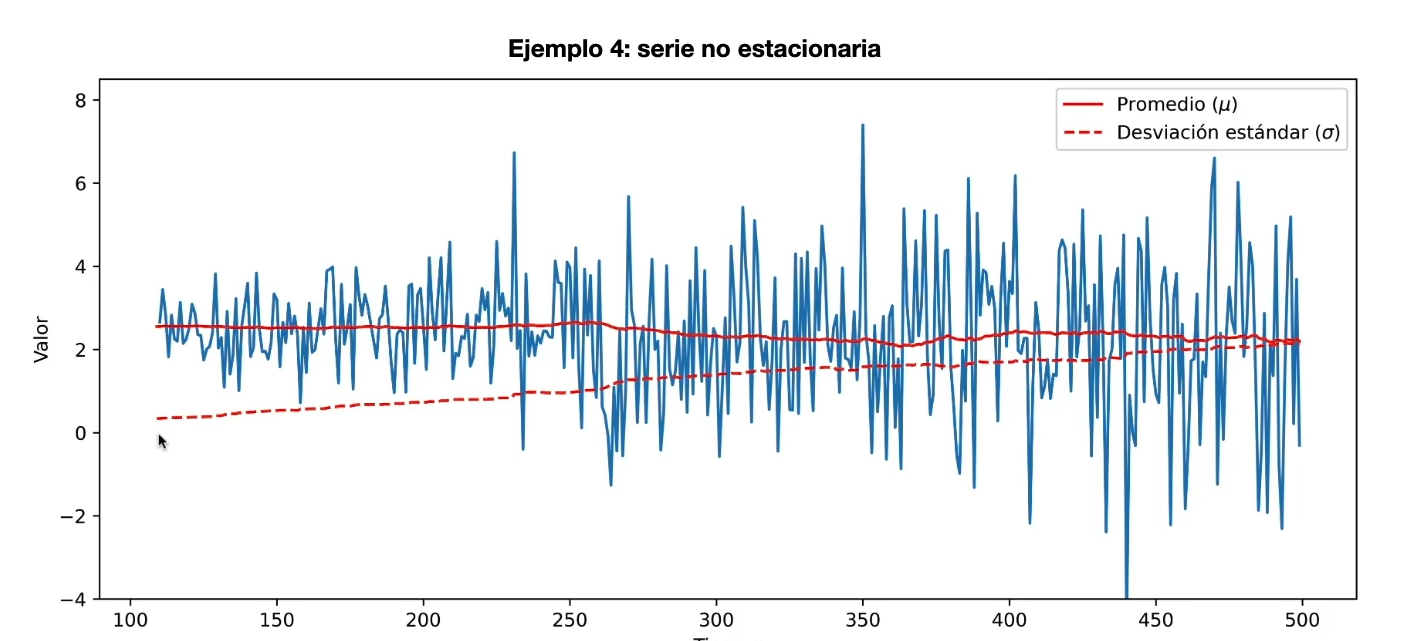

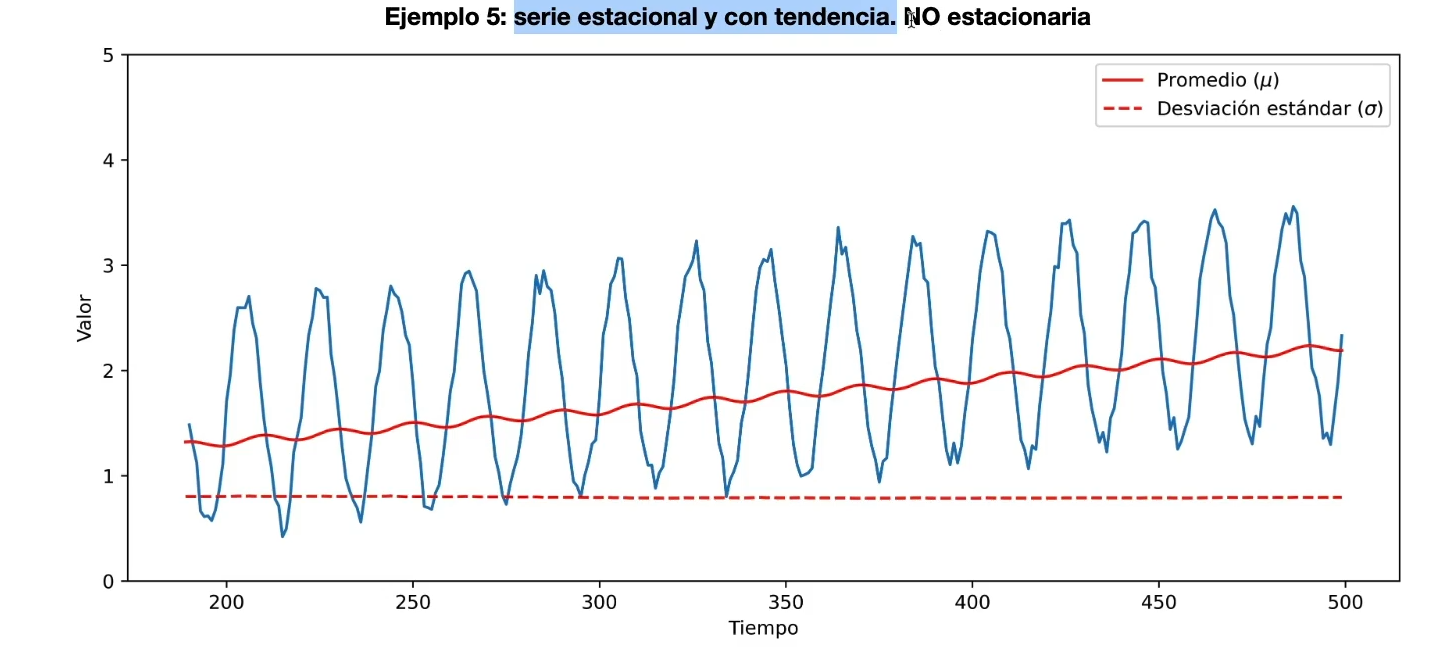

### Raíz unitaria de una serie de tiempo

Digamos que asumimos este sencillo modelo:

$$y_t = \phi y_{t-1} + \epsilon_t$$

donde:

- $y_t$ es el valor futuro de la Serie (el valor que queremos predecir)
- $y_{t-1}$ es el valor presente de la Serie (el que usaremos como referencia para generar la predicción)
- $\epsilon_t$ es un término aleatorio que representa el componente intrínseco de la Serie de Tiempo que no podemos representar con $y_{t-1}$
- $\phi$ es un coeficiente que debemos encontrar con el fin de generar las mejores predicciones

Con base en este sencillo modelo consideremos tres diferentes situaciones para el valor de $|\phi|$:

- $|\phi| > 1$ **NO es estacionaria**
- $|\phi| = 1$ **NO es estacionaria y raíz unitaria**
- $|\phi| < 1$ **Totalmente estacionaria**

Text(0, 0.5, 'Valores')

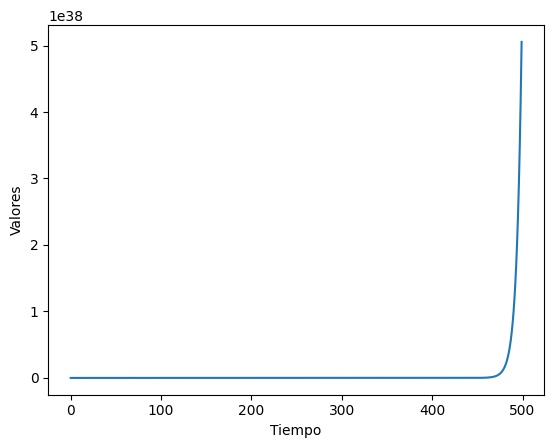

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

PHI = 1.2 # PHI > 1
y = [0.1] # y0 = 0.1, y1 = 1.2*y0 + e_t, y2 = 1.2*y1 + e_t...

# Generar 500 muestras de la serie
for i in range(1,500):
    pred = PHI*y[i-1] + 0.05*np.random.randn()
    y.append(pred)

# Graficar la serie resultante
plt.plot(y)
plt.xlabel('Tiempo')
plt.ylabel('Valores')


# El promedio deja de ser constante y por eso la serie no es estacionaria

Text(0, 0.5, 'Valores')

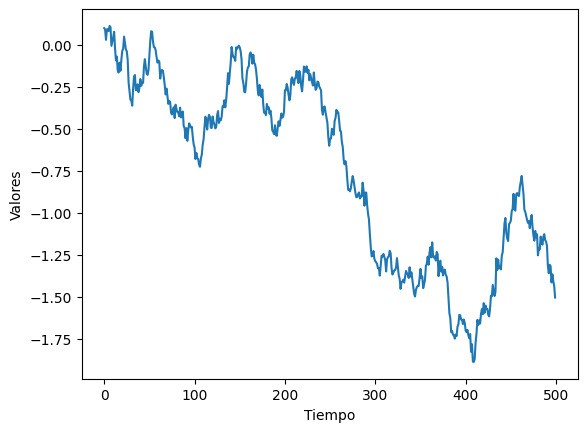

In [ ]:
PHI = 1 # PHI = 1
y = [0.1] # y0 = 0.1, y1 = 1*y0 + e_t, y2 = 1*y1 + e_t...

# Generar 500 muestras de la serie
for i in range(1,500):
    pred = PHI*y[i-1] + 0.05*np.random.randn()
    y.append(pred)

# Graficar la serie resultante
plt.plot(y)
plt.xlabel('Tiempo')
plt.ylabel('Valores')

# Tienen una tendencia, por lo que la media no es constante y por lo tanto no es estacionaria

Text(0, 0.5, 'Valores')

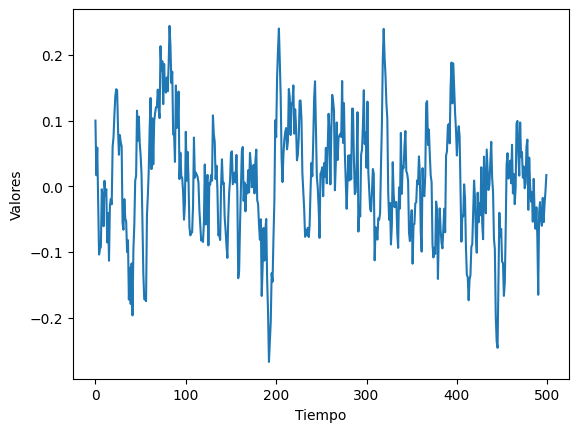

In [ ]:
PHI = 0.8 # PHI < 1
y = [0.1] # y0 = 0.1, y1 = 0.8*y0 + e_t, y2 = 0.8*y1 + e_t...

# Generar 500 muestras de la serie
for i in range(1,500):
    pred = PHI*y[i-1] + 0.05*np.random.randn()
    y.append(pred)

# Graficar la serie resultante
plt.plot(y)
plt.xlabel('Tiempo')
plt.ylabel('Valores')

# Presenta una media constante y las oscilaciones se mantenienen mas o menos estables, por lo que si es estacionaria

### Prueba de Dickey-Fuller

> Prueba estadística para saber si una serie de tiempo es estacionaria o no. Determina si la serie tiene o no una raíz unitaria *$|\phi| = 1$*

Las hipótesis de este test son:

- $H_0$ (hipótesis nula): $|\phi|=1$ (la serie tiene una raíz unitaria) $\rightarrow$ la serie es NO estacionaria
- $H_1$ (hipótesis alterna): $|\phi|<1$ (la serie NO tiene una raíz unitaria) $\rightarrow$ la serie es estacionaria

Y estos son los pasos para aplicar la prueba:

1. Se estima el valor de $\phi$ a partir de la Serie de Tiempo
2. Se calcula el valor p 
3. Y si:
    - $p < \alpha$ ($\alpha$: nivel de significancia) se rechaza la hipótesis nula $\rightarrow$ **la serie es estacionaria**
    - $p \geq \alpha$ es acepta la hipótesis nula $\rightarrow$ **la serie NO es estacionaria**

### Ejemplos

In [18]:
from statsmodels.tsa.stattools import adfuller
def definir_estacionaria(serie):
    p = adfuller(serie)[1]

    if p < 0.05:
        print('Serie Estacionaria')
        print(f'p value {p} < 0.05')
    else:
        print('Serie No Estacionaria')
        print(f'p value {p} >= 0.05')

Serie No Estacionaria
p value 1.0 >= 0.05


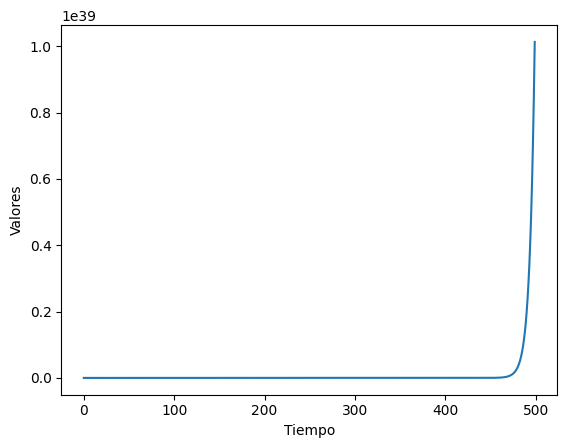

In [19]:

PHI = 1.2 # PHI > 1
y = [0.1] # y0 = 0.1, y1 = 1.2*y0 + e_t, y2 = 1.2*y1 + e_t...

# Generar 500 muestras de la serie
for i in range(1,500):
    pred = PHI*y[i-1] + 0.05*np.random.randn()
    y.append(pred)

# Graficar la serie resultante
plt.plot(y)
plt.xlabel('Tiempo')
plt.ylabel('Valores')

definir_estacionaria(y)

Serie No Estacionaria
p value 0.43005177674219175 >= 0.05


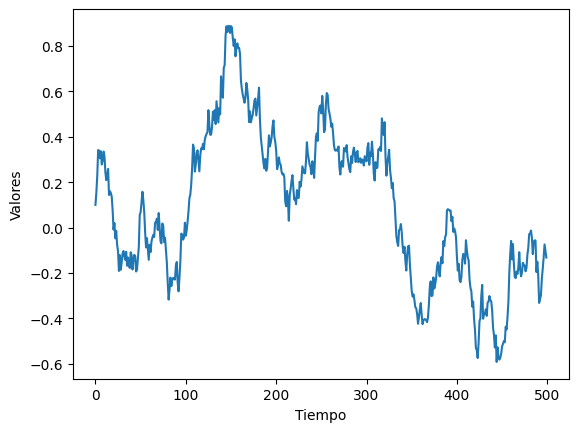

In [33]:
PHI = 1 # PHI = 1
y = [0.1] # y0 = 0.1, y1 = 1*y0 + e_t, y2 = 1*y1 + e_t...

# Generar 500 muestras de la serie
for i in range(1,500):
    pred = PHI*y[i-1] + 0.05*np.random.randn()
    y.append(pred)

# Graficar la serie resultante
plt.plot(y)
plt.xlabel('Tiempo')
plt.ylabel('Valores')

definir_estacionaria(y)

Serie Estacionaria
p value 7.843004685096005e-14 < 0.05


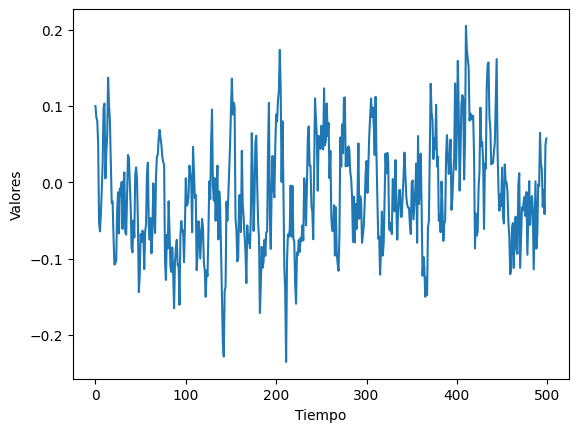

In [40]:
PHI = 0.8 # PHI < 1
y = [0.1] # y0 = 0.1, y1 = 0.8*y0 + e_t, y2 = 0.8*y1 + e_t...

# Generar 500 muestras de la serie
for i in range(1,500):
    pred = PHI*y[i-1] + 0.05*np.random.randn()
    y.append(pred)

# Graficar la serie resultante
plt.plot(y)
plt.xlabel('Tiempo')
plt.ylabel('Valores')

definir_estacionaria(y)